In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pandas.api.types import CategoricalDtype
import scipy as sp
from pathlib import Path
import tkinter as tk
from tkinter import filedialog
import itertools
from colour import Color
from datetime import date

In [2]:
today = date.today()
print("Today's date:", today)
date_today = str(today)
date_today

Today's date: 2022-10-03


'2022-10-03'

In [3]:
tubulin = '[Tubulin] ' r'$(\mu M)$'
tub = 'tub'

DCXconc = '[DCX] ' r'$(n M)$'
DCX = 'DCX'
Type = 'DCX Type'

taxol = '[Taxol] ' r'$(\mu M)$'

Concentration = 'Concentration ' r'$(\mu M)$'
Length = 'Length ' r'$(\mu m)$'
Lifetime = 'Lifetime ' r'$(min)$'
GrowthRate = 'Growth Rate ' r'$(\mu m / min)$'
TimeToNucleate = 'Time to Nucleate ' r'$(min)$'
ShrinkageLength = 'Shrink Length ' r'$(\mu m)$'
ShrinkageLifetime = 'Shrink Lifetime ' r'$(min)$'
ShrinkageRate = 'Shrink Rate ' r'$(\mu m / min)$'

In [4]:
black = '#000000'
grey = '#777777'
blue = '#23459C'
snsblue = '#225b91'
cyan = '#0089CF'
green = '#79BA1A'
purple = '#AB4A9C'
lily = '#CB81EA'
magenta = '#D80B8C'
red = '#e60000'
orange = '#FF7300'
darkorange = '#FF5B00'
lightorange = '#FFAC83'
yellow = '#FFCB05'
lightyellow = '#F9DC2D'
pink = '#FFA4CD'
StartHue1 = Color(purple)
DC1color = list(StartHue1.range_to(Color(pink),3))
StartHue2 = Color(darkorange)
DC2color = list(StartHue2.range_to(Color(lightorange),3))
print(DC1color,DC2color)

palette = [grey,cyan] + list(map(Color.get_hex,DC1color)) + list(map(Color.get_hex,DC2color)) + [green]
parameters = [GrowthRate,TimeToNucleate,Lifetime,ShrinkageRate]

[<Color #ab4a9c>, <Color #e468b8>, <Color #ffa4cd>] [<Color #ff5b00>, <Color #ff8341>, <Color #ffac83>]


## Import Kappa csv ##

In [47]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)

In [48]:
files = [x for x in path.iterdir() if x.is_file()]
files = [i for i in files if (str(i)[-9:] == 'final.csv') == True]
files

[WindowsPath('D:/Sofia/2022_2summer-fall/2022-09-29-taxol-R89G/CH3_DCXGFP8.0nM_typeR89G_20P-yes/4-Stack_Composite-final.csv'),
 WindowsPath('D:/Sofia/2022_2summer-fall/2022-09-29-taxol-R89G/CH3_DCXGFP8.0nM_typeR89G_20P-yes/5-Stack_Composite-final.csv'),
 WindowsPath('D:/Sofia/2022_2summer-fall/2022-09-29-taxol-R89G/CH3_DCXGFP8.0nM_typeR89G_20P-yes/6-Stack_Composite-final.csv'),
 WindowsPath('D:/Sofia/2022_2summer-fall/2022-09-29-taxol-R89G/CH3_DCXGFP8.0nM_typeR89G_20P-yes/7-Stack_Composite-final.csv')]

In [27]:
i = files[0]
dateloc = str(i).rfind("202")   
dates = str(i)[dateloc : dateloc+10]

CHlocstart = str(i).find("CH") 
CHlocend = str(i).find('_', CHlocstart)
CH = str(i)[CHlocstart+2: CHlocend]

DCXGFPstart = str(i).find('DCXGFP')
DCXGFPend = str(i).find('nM',DCXGFPstart)
DCXGFP = str(i)[DCXGFPstart+6: DCXGFPend]

DCXtypestart = str(i).find('type')
DCXtypeend = str(i).find('_',DCXtypestart)
DCXtype = str(i)[DCXtypestart+4: DCXtypeend]


dates,CH,DCXGFP,DCXtype

('2022-09-29', '3', '8.0', 'R89G')

In [28]:
roll = 5

joindata = pd.DataFrame(columns=[] , index=[])
for i in files:
    data0 = pd.read_csv(i, encoding='utf-8')
    
    for j in data0['Curve Name'].unique():
        curvedata = data0[data0['Curve Name'] == j]
        array = curvedata['Red Intensity'].values
        curvedata['Normal Intensity'] =  (array - min(array)) / (max(array) - min(array))
        
        curvedata['Date'] = dates
        curvedata['CH'] = CH
        curvedata[DCXconc] = DCXGFP
        curvedata[Type] = DCXtype
        curvedata['Filename'] = i.stem
        
        joindata = joindata.append(curvedata, ignore_index=True)
    
joindata


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # Remove the CWD from sys.path while we load stuff.
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value i

,Curve Name,Curve Length (um),Average Curvature (um-1),Curvature Std (um-1),X-Coordinate (um),Y-Coordinate (um),Point Curvature (um-1),Point Curvature Sign,Red Intensity,Green Intensity,Blue Intensity,Normal Intensity,Date,CH,[DCX] $(n M)$,DCX Type,Filename
0,CURVE 1,18.205300,0.396566,0.312130,40.553100,5.909861,0.061993,1,792.0,274.0,274.0,0.268484,2022-09-29,3,8.0,R89G,4-Stack_Composite-final
1,CURVE 1,18.205300,0.396566,0.312130,40.511124,5.912464,0.063816,1,854.0,266.0,266.0,0.291636,2022-09-29,3,8.0,R89G,4-Stack_Composite-final
2,CURVE 1,18.205300,0.396566,0.312130,40.469681,5.915146,0.065701,1,854.0,266.0,266.0,0.291636,2022-09-29,3,8.0,R89G,4-Stack_Composite-final
3,CURVE 1,18.205300,0.396566,0.312130,40.428767,5.917905,0.067651,1,931.0,232.0,232.0,0.320388,2022-09-29,3,8.0,R89G,4-Stack_Composite-final
4,CURVE 1,18.205300,0.396566,0.312130,40.388378,5.920740,0.069669,1,931.0,232.0,232.0,0.320388,2022-09-29,3,8.0,R89G,4-Stack_Composite-final
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19195,CURVE 7,8.822166,0.192883,0.110771,51.490338,3.542023,0.043046,1,187.0,441.0,441.0,0.081767,2022-09-29,3,8.0,R89G,7-Stack_Composite-final
19196,CURVE 7,8.822166,0.192883,0.110771,51.505162,3.508556,0.042118,1,256.0,472.0,472.0,0.111937,2022-09-29,3,8.0,R89G,7-Stack_Composite-final
19197,CURVE 7,8.822166,0.192883,0.110771,51.520077,3.474744,0.041211,1,256.0,472.0,472.0,0.111937,2022-09-29,3,8.0,R89G,7-Stack_Composite-final
19198,CURVE 7,8.822166,0.192883,0.110771,51.535082,3.440586,0.040323,1,256.0,472.0,472.0,0.111937,2022-09-29,3,8.0,R89G,7-Stack_Composite-final


In [49]:
newdirectory = str(path.parents[1])+'//Curvature_Data_Sheets'
newmydir = Path(newdirectory)
newmydir.mkdir(exist_ok=True)
newmydir

WindowsPath('D:/Sofia/2022_2summer-fall/Curvature_Data_Sheets')

In [30]:
joindata.to_csv(newmydir/(dates+'_'+CH + '_jointdata-on_'+date_today +'.csv'), encoding='utf-8', index=False)
joindata.to_csv(path/(dates+'_'+CH + '_jointdata-on_'+date_today +'.csv'), encoding='utf-8', index=False)

### open data sheets ###

In [50]:
#askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = newmydir
path

WindowsPath('D:/Sofia/2022_2summer-fall/Curvature_Data_Sheets')

In [57]:
files = [x for x in path.iterdir() if x.is_file()]
files = [i for i in files if (str(i)[-9:] != 'Sheet.csv') == True]
files = [i for i in files if str(i).rfind('csv') != -1 if str(i).rfind('jointdata') != -1]

files

[WindowsPath('D:/Sofia/2022_2summer-fall/Curvature_Data_Sheets/2022-09-29_1_jointdata-on_2022-09-30.csv'),
 WindowsPath('D:/Sofia/2022_2summer-fall/Curvature_Data_Sheets/2022-09-29_2_jointdata-on_2022-09-30.csv'),
 WindowsPath('D:/Sofia/2022_2summer-fall/Curvature_Data_Sheets/2022-09-29_3_jointdata-on_2022-10-03.csv')]

In [58]:
joindata = pd.read_csv(files[0], encoding='utf-8')
for i in range(1,len(files)):
    d = pd.read_csv(files[i], encoding='utf-8')
    joindata = joindata.append(d, ignore_index=True)

joindata.to_csv(path/('jointdata-on_'+date_today +'_MasterSheet.csv'), encoding='utf-8', index=False)
joindata

,Curve Name,Curve Length (um),Average Curvature (um-1),Curvature Std (um-1),X-Coordinate (um),Y-Coordinate (um),Point Curvature (um-1),Point Curvature Sign,Red Intensity,Green Intensity,Blue Intensity,Normal Intensity,Date,CH,[DCX] $(n M)$,DCX Type,Filename
0,CURVE 1,22.405892,0.173045,0.118131,31.233510,27.257117,0.031528,-1,639.0,541.0,541.0,0.334730,2022-09-29,1,8.0,R89G,1-Stack_Composite-final
1,CURVE 1,22.405892,0.173045,0.118131,31.157596,27.261825,0.031950,-1,639.0,541.0,541.0,0.334730,2022-09-29,1,8.0,R89G,1-Stack_Composite-final
2,CURVE 1,22.405892,0.173045,0.118131,31.082349,27.266309,0.032374,-1,402.0,619.0,619.0,0.210581,2022-09-29,1,8.0,R89G,1-Stack_Composite-final
3,CURVE 1,22.405892,0.173045,0.118131,31.007764,27.270572,0.032801,-1,365.0,645.0,645.0,0.191200,2022-09-29,1,8.0,R89G,1-Stack_Composite-final
4,CURVE 1,22.405892,0.173045,0.118131,30.933839,27.274616,0.033231,-1,365.0,645.0,645.0,0.191200,2022-09-29,1,8.0,R89G,1-Stack_Composite-final
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54779,CURVE 7,8.822166,0.192883,0.110771,51.490338,3.542023,0.043046,1,187.0,441.0,441.0,0.081767,2022-09-29,3,8.0,R89G,7-Stack_Composite-final
54780,CURVE 7,8.822166,0.192883,0.110771,51.505162,3.508556,0.042118,1,256.0,472.0,472.0,0.111937,2022-09-29,3,8.0,R89G,7-Stack_Composite-final
54781,CURVE 7,8.822166,0.192883,0.110771,51.520077,3.474744,0.041211,1,256.0,472.0,472.0,0.111937,2022-09-29,3,8.0,R89G,7-Stack_Composite-final
54782,CURVE 7,8.822166,0.192883,0.110771,51.535082,3.440586,0.040323,1,256.0,472.0,472.0,0.111937,2022-09-29,3,8.0,R89G,7-Stack_Composite-final


### If data already joint ###

In [5]:
askfile = filedialog.askopenfilename()
joindata = pd.read_csv(askfile, encoding='utf-8')

In [6]:
path = Path(askfile).parents[0]
path

WindowsPath('D:/Sofia/2022_2summer-fall/Curvature_Data_Sheets')

## Analysis & Plot starts ##

In [59]:
alldata = joindata[['Point Curvature (um-1)','Red Intensity','Green Intensity','Date','Filename','Curve Name','CH']]
alldata.groupby(['Date', 'Filename'])["Red Intensity"].min()

Date        Filename               
2022-09-29  1-Stack_Composite-final    0.0
            2-Stack_Composite-final    0.0
            3-Stack_Composite-final    0.0
            4-Stack_Composite-final    0.0
            5-Stack_Composite-final    0.0
            6-Stack_Composite-final    0.0
            7-Stack_Composite-final    0.0
Name: Red Intensity, dtype: float64

In [60]:
maxcurve = alldata.groupby(['Date','CH', 'Filename'])["Point Curvature (um-1)"].max()
#maxcurve.to_csv(path/('maxcurvedata-on_'+date_today +'.csv'), encoding='utf-8', index=False)

In [61]:
maxcurve

Date        CH  Filename               
2022-09-29  1   1-Stack_Composite-final    0.440879
                2-Stack_Composite-final    0.809961
                3-Stack_Composite-final    1.271640
                4-Stack_Composite-final    0.755881
            2   1-Stack_Composite-final    0.942591
                2-Stack_Composite-final    1.372314
                3-Stack_Composite-final    1.010721
                4-Stack_Composite-final    1.985394
            3   4-Stack_Composite-final    1.317198
                5-Stack_Composite-final    1.018280
                6-Stack_Composite-final    2.771196
                7-Stack_Composite-final    1.641112
Name: Point Curvature (um-1), dtype: float64

In [62]:
def normal_int(df,channel):
    
    max_RFP = df.groupby(['Date', 'Filename'])[channel].max()
    min_RFP = df.groupby(['Date', 'Filename'])[channel].min()
    
    equal_int = pd.DataFrame(columns=[] , index=[])

    uniquedates = df['Date'].unique()
    for i in uniquedates:
        uniquefile =  df[df['Date'] == i]['Filename'].unique()

        for j in uniquefile:
            groupdf = df[(df['Date'] == i) & (df['Filename'] == j)]
            
            max_RFP_value = max_RFP[i,j]
            min_RFP_value = min_RFP[i,j]

            groupdf['Normalized DCX-GFP Intensity'] = (df[channel] - min_RFP_value) / (max_RFP_value -  min_RFP_value)
            
            equal_int = pd.concat([equal_int, groupdf])
    return equal_int

In [63]:
data = normal_int(alldata,"Red Intensity")

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [64]:

data = data.sort_values(by=['Point Curvature (um-1)'])

roll = 100

data['Rolling Intensity'] =  data['Normalized DCX-GFP Intensity'].rolling(roll, min_periods=1, center=True).mean()
data['Rolling Intensity std'] =  data['Normalized DCX-GFP Intensity'].rolling(roll, min_periods=1, center=True).std()

data

,Point Curvature (um-1),Red Intensity,Green Intensity,Date,Filename,Curve Name,CH,Normalized DCX-GFP Intensity,Rolling Intensity,Rolling Intensity std
14671,9.786681e-08,97.0,276.0,2022-09-29,1-Stack_Composite-final,CURVE 9,2,0.034095,0.254998,0.275846
1073,2.188388e-07,421.0,746.0,2022-09-29,1-Stack_Composite-final,CURVE 2,1,0.147979,0.256042,0.273176
15509,1.885119e-06,144.0,238.0,2022-09-29,1-Stack_Composite-final,CURVE 11,2,0.050615,0.260309,0.272228
8137,2.955420e-06,71.0,803.0,2022-09-29,3-Stack_Composite-final,CURVE 2,1,0.023187,0.255815,0.271576
944,7.555269e-06,199.0,551.0,2022-09-29,1-Stack_Composite-final,CURVE 1,1,0.069947,0.260672,0.271359
...,...,...,...,...,...,...,...,...,...,...
47066,2.769492e+00,0.0,88.0,2022-09-29,6-Stack_Composite-final,CURVE 3,3,0.000000,0.002770,0.005931
47062,2.770122e+00,0.0,196.0,2022-09-29,6-Stack_Composite-final,CURVE 3,3,0.000000,0.002822,0.005975
47065,2.770702e+00,0.0,88.0,2022-09-29,6-Stack_Composite-final,CURVE 3,3,0.000000,0.002587,0.005776
47063,2.770996e+00,0.0,196.0,2022-09-29,6-Stack_Composite-final,CURVE 3,3,0.000000,0.002344,0.005551


In [65]:
curve = joindata.groupby(['Filename'])['Curve Name'].unique()
curveN = 0

for i in curve:
    j = len(i)
    curveN += j
curveN

66

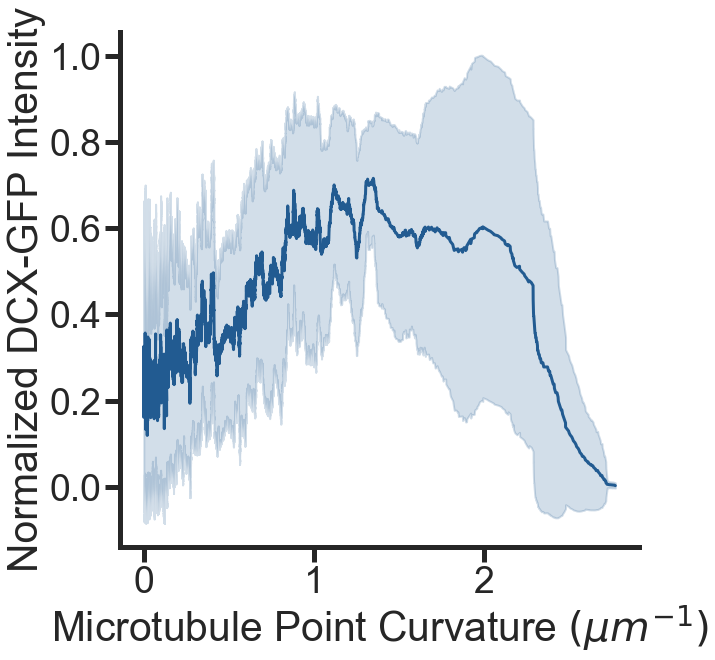

In [66]:
fig, ax = plt.subplots(1,1,figsize=(10.5,10))

x = data['Point Curvature (um-1)'].values
mean = data['Rolling Intensity'].values
std = data['Rolling Intensity std'].values

plt.plot(x, mean, color=snsblue)
plt.fill_between(x, mean - std, mean + std, color=snsblue, alpha=0.2)

ax.set_ylabel('Normalized DCX-GFP Intensity')
ax.set_xlabel('Microtubule Point Curvature ' r'$(\mu m ^{-1})$')
#ax.set_xlim(0,1.5)
#ax.set_ylim(0,0.8)

sns.set_style("ticks")
sns.despine()
ax.spines['left'].set_lw(5)
ax.spines['bottom'].set_lw(5)
ax.tick_params(axis='both', width = 5, length = 15)
sns.set_context("poster", font_scale=1.7, rc={"lines.linewidth":3.0})

plt.tight_layout()

#plt.savefig(path/('curvature_dcx_'+date_today+'.svg'))

In [67]:
dataT = normal_int(alldata,"Green Intensity")

dataT = dataT.sort_values(by=['Point Curvature (um-1)'])

roll = 100

dataT['Rolling Intensity'] =  dataT['Normalized DCX-GFP Intensity'].rolling(roll, min_periods=1, center=True).mean()
dataT['Rolling Intensity std'] =  dataT['Normalized DCX-GFP Intensity'].rolling(roll, min_periods=1, center=True).std()

dataT

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,Point Curvature (um-1),Red Intensity,Green Intensity,Date,Filename,Curve Name,CH,Normalized DCX-GFP Intensity,Rolling Intensity,Rolling Intensity std
14671,9.786681e-08,97.0,276.0,2022-09-29,1-Stack_Composite-final,CURVE 9,2,0.162405,0.320439,0.130330
1073,2.188388e-07,421.0,746.0,2022-09-29,1-Stack_Composite-final,CURVE 2,1,0.487215,0.316391,0.132218
15509,1.885119e-06,144.0,238.0,2022-09-29,1-Stack_Composite-final,CURVE 11,2,0.136144,0.313426,0.132650
8137,2.955420e-06,71.0,803.0,2022-09-29,3-Stack_Composite-final,CURVE 2,1,0.586131,0.309155,0.134998
944,7.555269e-06,199.0,551.0,2022-09-29,1-Stack_Composite-final,CURVE 1,1,0.352453,0.311295,0.134639
...,...,...,...,...,...,...,...,...,...,...
47066,2.769492e+00,0.0,88.0,2022-09-29,6-Stack_Composite-final,CURVE 3,3,0.025544,0.139640,0.061035
47062,2.770122e+00,0.0,196.0,2022-09-29,6-Stack_Composite-final,CURVE 3,3,0.127720,0.139704,0.061606
47065,2.770702e+00,0.0,88.0,2022-09-29,6-Stack_Composite-final,CURVE 3,3,0.025544,0.138270,0.061279
47063,2.770996e+00,0.0,196.0,2022-09-29,6-Stack_Composite-final,CURVE 3,3,0.127720,0.136780,0.060901


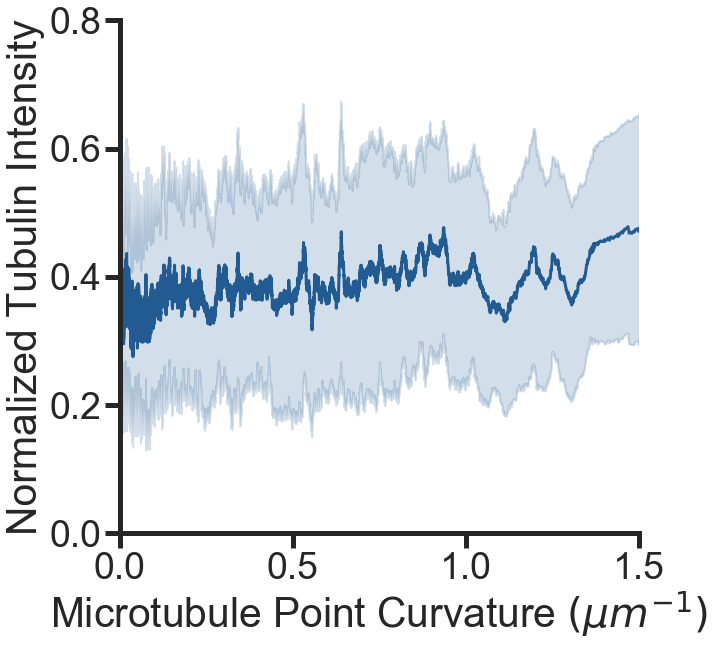

In [64]:
fig, ax = plt.subplots(1,1,figsize=(10.5,10))

x = dataT['Point Curvature (um-1)'].values
mean = dataT['Rolling Intensity'].values
std = dataT['Rolling Intensity std'].values

plt.plot(x, mean, color=snsblue)
plt.fill_between(x, mean - std, mean + std, color=snsblue, alpha=0.2)

ax.set_ylabel('Normalized Tubulin Intensity')
ax.set_xlabel('Microtubule Point Curvature ' r'$(\mu m ^{-1})$')
ax.set_xlim(0,1.5)
ax.set_ylim(0,0.8)

sns.set_style("ticks")
sns.despine()
ax.spines['left'].set_lw(5)
ax.spines['bottom'].set_lw(5)
ax.tick_params(axis='both', width = 5, length = 15)
sns.set_context("poster", font_scale=1.7, rc={"lines.linewidth":3.0})

plt.tight_layout()

plt.savefig(path/('curvature_tub_'+date_today+'.svg'))

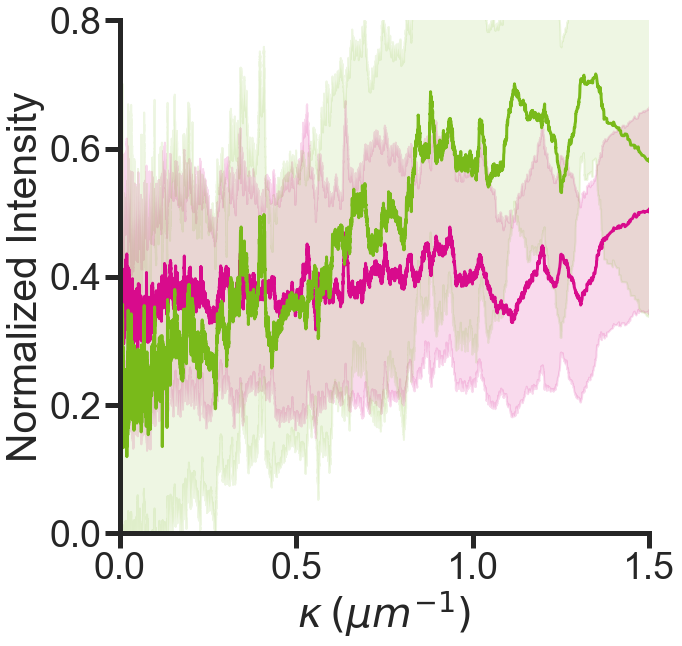

In [68]:
fig, ax = plt.subplots(1,1,figsize=(10.5,10))

x = dataT['Point Curvature (um-1)'].values
mean = dataT['Rolling Intensity'].values
std = dataT['Rolling Intensity std'].values

color = magenta
plt.plot(x, mean, color=color, label='Atto633-Tubulin')
plt.fill_between(x, mean - std, mean + std, color=color, alpha=0.15)

x = data['Point Curvature (um-1)'].values
mean = data['Rolling Intensity'].values
std = data['Rolling Intensity std'].values

color = green
plt.plot(x, mean, color=color, label='DCX-R89G-GFP')
plt.fill_between(x, mean - std, mean + std, color=color, alpha=0.12)

#ax.legend( loc = 'lower right')

ax.set_ylabel('Normalized Intensity')
ax.set_xlabel( r'$\kappa \: (\mu m ^{-1})$')
#ax.set_xlabel( r'$\langle \kappa  \rangle = 1.15 \: \mu m ^{-1}$')
ax.set_xlim(0,1.5)
ax.set_ylim(0,0.8)

sns.set_style("ticks")
sns.despine()
ax.spines['left'].set_lw(5)
ax.spines['bottom'].set_lw(5)
ax.tick_params(axis='both', width = 5, length = 15)
sns.set_context("poster", font_scale=1.7, rc={"lines.linewidth":3.0})

plt.tight_layout()

plt.savefig(path/('curvature_test_'+date_today+'.svg'))

In [40]:
x = data['Point Curvature (um-1)'].values

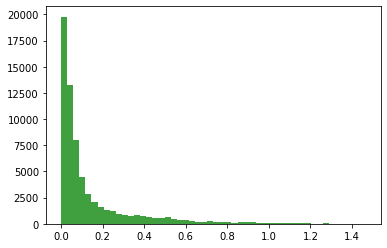

In [41]:
n, bins, patches = plt.hist(x, 50, facecolor='g', alpha=0.75)
#plt.ylim(0,30)

In [87]:
0.16/0.107*0.96


1.435514018691589

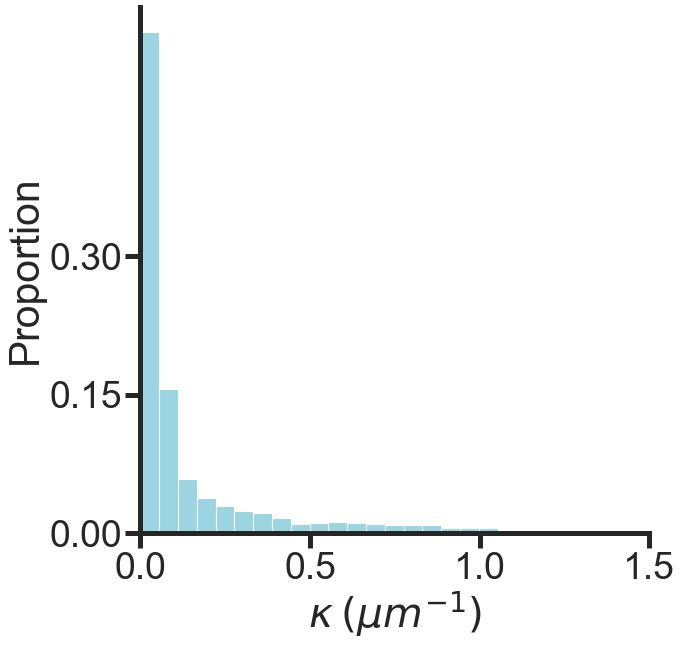

In [71]:
fig, ax = plt.subplots(1,1,figsize=(10.5,10))
sns.histplot(data, x='Point Curvature (um-1)', stat='probability',bins=50, color='#7BC8D9')
#n, bins, patches = plt.hist(x, 50, density = True, facecolor='#7BC8D9')

ax.set_ylabel('Proportion')
ax.set_xlabel( r'$\kappa \: (\mu m ^{-1})$')
ax.set_xlim(0,1.5)
plt.yticks([0,0.15,0.3])

sns.set_style("ticks")
sns.despine()
ax.spines['left'].set_lw(5)
ax.spines['bottom'].set_lw(5)
ax.tick_params(axis='both', width = 5, length = 15)
sns.set_context("poster", font_scale=1.7, rc={"lines.linewidth":3.0})

plt.tight_layout()

plt.savefig(path/('histogram_curves'+date_today+'.svg'))

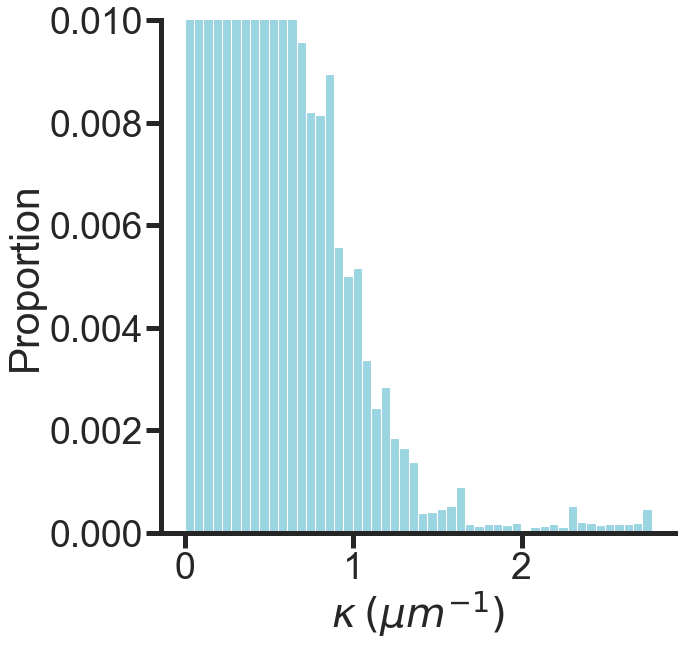

In [75]:
fig, ax = plt.subplots(1,1,figsize=(10.5,10))
sns.histplot(data, x='Point Curvature (um-1)', stat='probability',bins=50, color='#7BC8D9')
#n, bins, patches = plt.hist(x, 50, density = True, facecolor='#7BC8D9')

ax.set_ylabel('Proportion')
ax.set_xlabel( r'$\kappa \: (\mu m ^{-1})$')
#ax.set_xlim(0,1.5)
ax.set_ylim(0,0.01)
#plt.yticks([0,0.15,0.3])

sns.set_style("ticks")
sns.despine()
ax.spines['left'].set_lw(5)
ax.spines['bottom'].set_lw(5)
ax.tick_params(axis='both', width = 5, length = 15)
sns.set_context("poster", font_scale=1.7, rc={"lines.linewidth":3.0})

plt.tight_layout()

#plt.savefig(path/('histogram_curves'+date_today+'.svg'))